# Model testing and validation

# Imports

In [29]:
import joblib
import scipy.sparse as sp
import pandas as pd
from sklearn.metrics import classification_report

## Import models

In [30]:
tfidf = joblib.load('csv/tfidf_dump.pkl')
model = joblib.load('csv/sentiment_model.pkl')

X_test  = sp.load_npz('csv/X_test.npz')
y_test  = pd.read_csv('csv/y_test.csv')['Sentiment']

# Testing

In [31]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, 
      target_names=['Neutral', 'Negative', 'Positive']))

              precision    recall  f1-score   support

     Neutral       0.91      0.87      0.89      5821
    Negative       0.88      0.90      0.89      4214
    Positive       0.87      0.89      0.88      3789

    accuracy                           0.89     13824
   macro avg       0.89      0.89      0.89     13824
weighted avg       0.89      0.89      0.89     13824



This model has an accuracy of 89% with a high precision of 91% in neutral and 87% in positive. 

# Visualisation

This is a confusion matrix, which is able to visualise the accuracy of the a model, and how it performed in the test. 

Using the testing data, we can use `sklearn`s confusion_matrix function to create a heatmap and plot it. 

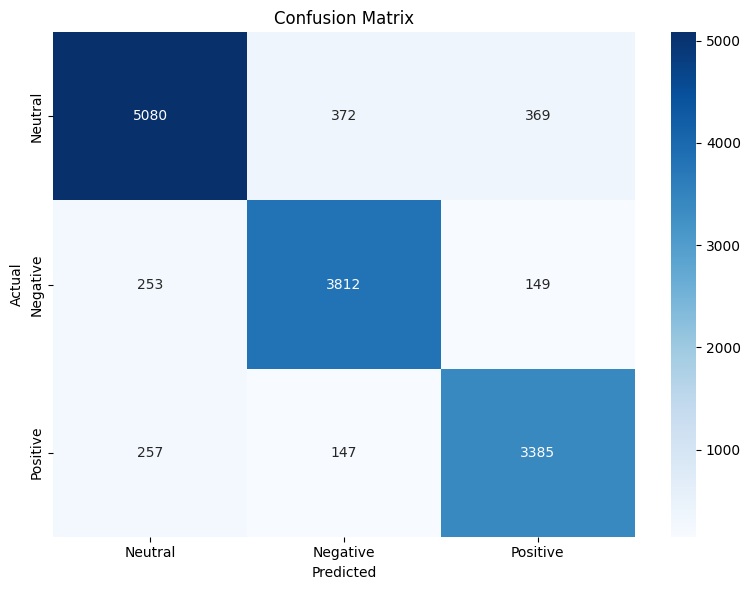

In [32]:
# disclaimer: block was gen by ai
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral', 'Negative', 'Positive'],
            yticklabels=['Neutral', 'Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Observations

The model looks to have difficulty differentiating between neutral and positive/negative data. Based on our initial analysis in Step 0 of the pipeline, we have combined `Neutral` and `Irrelevant` sentiments together (total: 30893), which creates more data. With more data creates a more error 